In [240]:
from tensorflow.keras.datasets import cifar10
(X_train,y_train),(X_test,y_test)=cifar10.load_data()


In [241]:
(X_train.shape,y_train.shape),(X_test.shape,y_test.shape)

(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

In [242]:
# normalize pixels values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# reshape

X_train=X_train.reshape(-1,32,32,3)
X_test=X_test.reshape(-1,32,32,3)

In [243]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [244]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout

model=Sequential()

# first layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# second layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# third layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))


model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [245]:
# compile model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,202 (625.79 KB)

 Trainable params: 160,202 (625.79 KB)

 Non-trainable params: 0 (0.00 B)

In [246]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [247]:
# train model
model_history=model.fit(X_train,y_train,epochs=20,batch_size=64,validation_data=(X_test,y_test),callbacks=[early_stopping])


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.3945 - loss: 1.6356 - val_accuracy: 0.5098 - val_loss: 1.3738
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5351 - loss: 1.2902 - val_accuracy: 0.5935 - val_loss: 1.1536
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5871 - loss: 1.1609 - val_accuracy: 0.6270 - val_loss: 1.0613
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6242 - loss: 1.0658 - val_accuracy: 0.6571 - val_loss: 0.9844
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6488 - loss: 0.9920 - val_accuracy: 0.6659 - val_loss: 0.9538
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6693 - loss: 0.9387 - val_accuracy: 0.6779 - val_loss: 0.9241
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6860 - loss: 0.8930 - val_accuracy: 0.7053 - val_loss: 0.8535
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6980 - loss: 0.8562 - val_accuracy: 

In [255]:
(test_loss,test_accuracy)=model.evaluate(X_test,y_test)
print('Test loss: {}'.format(test_loss))
print('Test accuracy: {}'.format(test_accuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7580 - loss: 0.7197
Test loss: 0.7197313904762268
Test accuracy: 0.7580000162124634


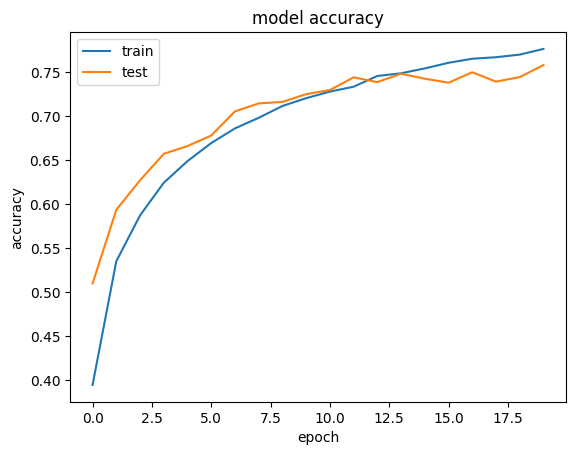

In [256]:
# summarize history from model
import matplotlib.pyplot as plt
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.title('model accuracy')
plt.show()

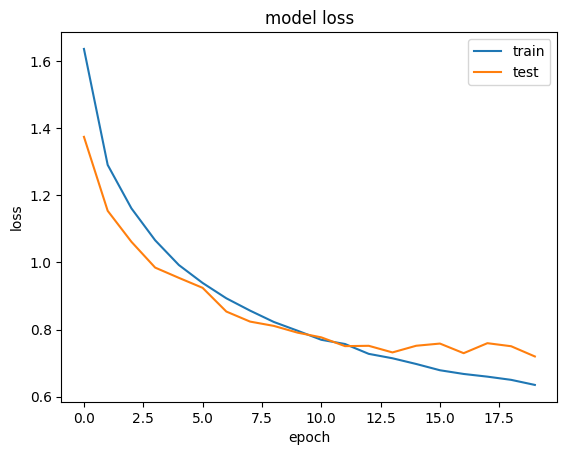

In [257]:
# summarize history loss from model
import matplotlib.pyplot as plt
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.title('model loss')
plt.show()

In [258]:
# test on one record
classNames=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)
print("Actual:",classNames[y_test[2][0]])
print("Predicted:",classNames[y_pred[2]])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Actual: ship
Predicted: ship


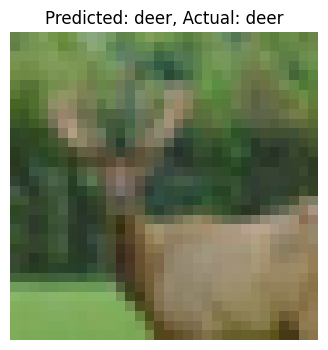

In [259]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))

plt.imshow(X_test[876])
plt.title(
    f"Predicted: {classNames[y_pred[876]]}, Actual: {classNames[y_test[876][0]]}"
)
plt.axis("off")
plt.show()

In [260]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.72      0.85      0.78      1000
           1       0.84      0.89      0.87      1000
           2       0.71      0.59      0.64      1000
           3       0.64      0.53      0.58      1000
           4       0.69      0.76      0.72      1000
           5       0.71      0.64      0.67      1000
           6       0.83      0.81      0.82      1000
           7       0.78      0.83      0.80      1000
           8       0.80      0.86      0.83      1000
           9       0.84      0.83      0.84      1000

    accuracy                           0.76     10000
   macro avg       0.76      0.76      0.75     10000
weighted avg       0.76      0.76      0.75     10000



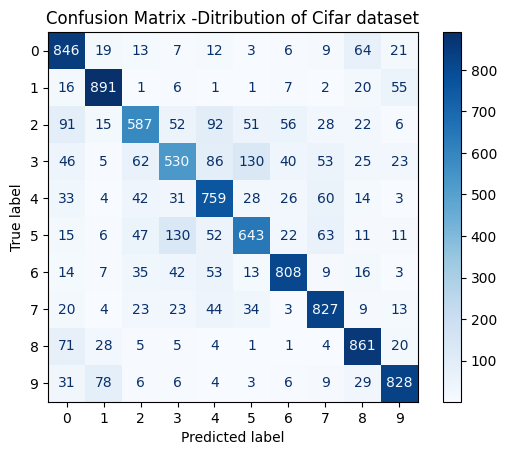

In [261]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Blues")
plt.title("Confusion Matrix -Ditribution of Cifar dataset")
plt.show()